# **Séries temporais do sensor *Wide-Field Imager* (WFI) para classificação de áreas queimadas no Cerrado**

### **Classificação com Random Forest [5/5]**

Vimos, no *notebook* anterior (04_classificacao_random_forest.ipynb), como fazer uma classificação supervisionada com o *Random Forest*, usando os rótulos disponíveis no *dataset* com o qual temos trabalhado.

Relembrando: com base nas amostras com datas associadas nas colunas date_20 e/ou date_21, filtramos as células que contêm áreas queimadas e que não têm áreas queimadas, tornando a nossa tarefa em um problema binário.

Agora daremos mais um passo e tentaremos responder: **o que, no fim das contas, *precision* e *recall* significam no mundo real?**

Nosso objetivo é visualizar suas implicaçõs nas predições do ano de 2022. Para isso, faremos o mesmo que no *script* anterior: treinaremos um modelo *Random Forest* com amostras de 2020 e 2021, e generalizaremos o modelo sobre as observações de 2022.

Para compreender melhor o *dataset* explorado, consulte: https://doi.org/10.1080/20964471.2025.2463731

**1) *Download* e preparação dos dados**

Antes de iniciarmos a análise, precisamos obter a base de dados. O conjunto utilizado neste exercício está disponível publicamente e reúne os registros do sensor WFI entre 2020 e 2022. Convertamos o arquivo CSV para Parquet, um formato mais eficiente para leitura e manipulação de grandes volumes de dados.

Diferentemente dos *scripts* anteriores, aqui baixaremos a grade vetorial com as células de 500 m x 500 m no formato *geopackage* (.gpkg).

**Observação**: esse *dataset* contém diversas outras colunas, mas neste exercício focaremos nas colunas que contêm as reflectâncias TOA (*top of atmosphere*) da banda NIR (colunas com o prefixo 'd'). Para entender melhor o *dataset*, consulte: https://doi.org/10.1080/20964471.2025.2463731

In [1]:
# ============================================
# FUNÇÕES AUXILIARES
# ============================================

import requests
from tqdm.auto import tqdm

def download(url: str, output: str) -> None:
    response = requests.get(url, stream=True)
    response.raise_for_status()

    total_size = int(response.headers.get("content-length", 0))

    with open(output, "wb") as f, tqdm(
        total=total_size,
        unit="B",
        unit_scale=True,
        desc=output.split("/")[-1],
    ) as pbar:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            f.write(chunk)
            pbar.update(len(chunk))

# ============================================
# DOWNLOAD E PREPARAÇÃO DOS DADOS
# ============================================

import pandas as pd
import os
import geopandas as gpd

# ----------------------------------------------------------------------------
# CAMINHOS E URLS
# ----------------------------------------------------------------------------

CSV_URL = "https://download.scidb.cn/download?fileId=e22fe8b8fa7b696516664d76a42ac2fe&path=/V4/Dataset_WFI.csv&fileName=Dataset_WFI.csv"
GPKG_URL = "https://download.scidb.cn/download?fileId=c92f0e7c61c5c11b8c822a625de1df83&path=/V5/gpk_spatial_grid.gpkg&fileName=gpk_spatial_grid.gpkg"

# Criar diretório no armazenamento temporário do Colab
BASE_DIR = "/content/ScienceDB/Dataset"
csv_path = os.path.join(BASE_DIR, "Dataset_WFI.csv")
parquet_path = os.path.join(BASE_DIR, "Dataset_WFI.parquet")
gpkg_path = os.path.join(BASE_DIR, "gpk_spatial_grid.gpkg")

# Criar diretório se não existir
os.makedirs(BASE_DIR, exist_ok=True)

# ----------------------------------------------------------------------------
# DOWNLOAD E CONVERSÃO DE CSV PARA PARQUET
# ----------------------------------------------------------------------------

if not os.path.exists(parquet_path):
    # Baixar CSV se necessário
    if not os.path.exists(csv_path):
        download(CSV_URL, csv_path)
    else:
        print(f"CSV já existe: {csv_path}")

    # Converter para Parquet (formato mais eficiente)
    print("Convertendo CSV para Parquet...")
    df = pd.read_csv(csv_path)
    df.to_parquet(parquet_path, compression="snappy")

    # Liberar memória e limpar
    del df
    os.remove(csv_path)
    print(f"Parquet salvo: {parquet_path}")
    print(f"CSV removido: {csv_path}")
else:
    print(f"Parquet já existe: {parquet_path}")

# ----------------------------------------------------------------------------
# DOWNLOAD DO GEOPACKAGE (PARA VISUALIZAÇÃO ESPACIAL)
# ----------------------------------------------------------------------------

if not os.path.exists(gpkg_path):
    print("\nBaixando Geopackage para visualização espacial...")
    download(GPKG_URL, gpkg_path)
    print(f"Geopackage salvo: {gpkg_path}")
else:
    print(f"Geopackage já existe: {gpkg_path}")

# ----------------------------------------------------------------------------
# VERIFICAÇÃO FINAL
# ----------------------------------------------------------------------------

print("\n" + "="*50)
print("ARQUIVOS DISPONÍVEIS:")
print("="*50)
print(f"Parquet: {parquet_path}")
print(f"Geopackage: {gpkg_path}")
print("\nAmbiente pronto para análise!")

Dataset_WFI.csv:   0%|          | 0.00/2.26G [00:00<?, ?B/s]

Convertendo CSV para Parquet...


/tmp/ipykernel_22375/1455443268.py:61: DtypeWarning: Columns (9856,9857,9858) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Parquet salvo: /content/ScienceDB/Dataset/Dataset_WFI.parquet
CSV removido: /content/ScienceDB/Dataset/Dataset_WFI.csv

Baixando Geopackage para visualização espacial...


gpk_spatial_grid.gpkg:   0%|          | 0.00/8.31M [00:00<?, ?B/s]

Geopackage salvo: /content/ScienceDB/Dataset/gpk_spatial_grid.gpkg

ARQUIVOS DISPONÍVEIS:
Parquet: /content/ScienceDB/Dataset/Dataset_WFI.parquet
Geopackage: /content/ScienceDB/Dataset/gpk_spatial_grid.gpkg

Ambiente pronto para análise!


**2) Preparação dos dados para classificação**

A abordagem com dados diários apresentou o melhor desempenho (*F1-score* de 0,576 no teste com 2022) no *notebook* anterior. Por isso, neste *notebook* focaremos **exclusivamente na série temporal diária**.

Para preparar os dados, seguiremos os passos:

a) Extração das colunas do NIR para cada ano (2020, 2021 e 2022)

b) Seleção de amostras de células com e sem áreas queimadas

c) Criação da matriz de *features* (série temporal diária com 365 dias) e os *labels* (1 = queimada, 0 = não queimada)

d) Preparação dos conjuntos de dados em treino (2020-2021) e teste (2022)

A novidade aqui é que **extrairemos e salvaremos as predições e probabilidades** para cada amostra de teste, pois usaremos elas para verificamos os impactos no *precision* e no *recall* quando aplicamos limiares permissivos (0,3) e restritivos (0,7).

In [1]:
# ============================================
# FUNÇÕES AUXILIARES PARA PREPARAÇÃO DOS DADOS
# ============================================

import numpy as np
import os
import pandas as pd
import geopandas as gpd

BASE_DIR = "/content/ScienceDB/Dataset"
parquet_path = os.path.join(BASE_DIR, "Dataset_WFI.parquet")
gpkg_path = os.path.join(BASE_DIR, "gpk_spatial_grid.gpkg")

def get_nir_cols(ano):
    """Retorna as colunas do NIR para um determinado ano."""
    return sorted([col for col in df.columns if col.startswith(f'd_{str(ano)[-2:]}')])

def get_pico_data(ano):
    """Retorna a data de pico de queimadas para um determinado ano."""
    col = f"date_{str(ano)[-2:]}"
    contagem = df[col].value_counts()
    contagem = contagem[contagem.index.notna()]
    if len(contagem) > 0:
        return contagem.idxmax()
    return None

def preparar_dados_classificacao(ano, n_amostras=1000):
    """
    Prepara os dados para classificação para um determinado ano (dados diários).

    Args:
        ano: Ano a ser analisado.
        n_amostras: Número de amostras por classe.

    Returns:
        X: Matriz de features (série temporal diária).
        y: Vetor de labels.
        indices: Lista de índices originais das amostras (para mapear com o Geopackage).
    """
    nir_cols = get_nir_cols(ano)
    pico_data = get_pico_data(ano)

    if not nir_cols or not pico_data:
        return None, None, None

    # Selecionar índices das células queimadas e não queimadas
    mask_queimada = df[f"date_{str(ano)[-2:]}"] == pico_data
    indices_queimada = df[mask_queimada].index.tolist()
    indices_sem_queimada = df[df[f"date_{str(ano)[-2:]}"].isna()].index.tolist()

    # Amostragem aleatória
    amostras_q = np.random.choice(indices_queimada, min(n_amostras, len(indices_queimada)), replace=False)
    amostras_sq = np.random.choice(indices_sem_queimada, min(n_amostras, len(indices_sem_queimada)), replace=False)

    # Preparar features e salvar índices
    X, y, indices = [], [], []

    for idx in amostras_q:
        serie = df.loc[idx, nir_cols].values
        X.append(serie)
        y.append(1)
        indices.append(idx)

    for idx in amostras_sq:
        serie = df.loc[idx, nir_cols].values
        X.append(serie)
        y.append(0)
        indices.append(idx)

    return np.array(X), np.array(y), indices

def combinar_dados(anos, n_amostras_por_ano=1000):
    """
    Combina dados de múltiplos anos para treino.
    """
    X_list, y_list, indices_list = [], [], []
    for ano in anos:
        X, y, indices = preparar_dados_classificacao(ano, n_amostras_por_ano)
        if X is not None:
            X_list.append(X)
            y_list.append(y)
            indices_list.extend(indices)
    return np.vstack(X_list), np.hstack(y_list), indices_list

# ============================================
# CARREGAR DADOS
# ============================================

print("Carregando dados...")
df = pd.read_parquet(parquet_path)
print(f"Dataset carregado: {df.shape[0]:,} linhas, {df.shape[1]:,} colunas")

# Carregar Geopackage para visualização posterior
print("\nCarregando Geopackage...")
gdf = gpd.read_file(gpkg_path)
print(f"Geopackage carregado: {gdf.shape[0]:,} células")
print(f"  - CRS: {gdf.crs}")
print(f"  - Colunas: {gdf.columns.tolist()[:5]}...")

# ============================================
# PREPARAR DADOS DE TREINO (2020-2021) E TESTE (2022)
# ============================================

print("\nPreparando dados para classificação...")
anos_treino = [2020, 2021]
n_amostras = 1000

# Dados de treino (incluindo índices)
X_train, y_train, idx_train = combinar_dados(anos_treino, n_amostras)

# Dados de teste (2022) (incluindo índices)
X_test, y_test, idx_test = preparar_dados_classificacao(2022, n_amostras)

print(f"\nDados de treino: {X_train.shape[0]:,} amostras")
print(f"  - Features: {X_train.shape[1]} dias")
print(f"  - Classe 0 (não queimada): {np.sum(y_train == 0)}")
print(f"  - Classe 1 (queimada): {np.sum(y_train == 1)}")

print(f"\nDados de teste:  {X_test.shape[0]:,} amostras")
print(f"  - Features: {X_test.shape[1]} dias")
print(f"  - Classe 0 (não queimada): {np.sum(y_test == 0)}")
print(f"  - Classe 1 (queimada): {np.sum(y_test == 1)}")

# Verificar se os índices do teste correspondem ao Geopackage
print(f"\nExemplo de índices de teste: {idx_test[:5]}")

Carregando dados...
Dataset carregado: 38,957 linhas, 9,862 colunas

Carregando Geopackage...
Geopackage carregado: 38,957 células
  - CRS: EPSG:4326
  - Colunas: ['id', 'geometry']...

Preparando dados para classificação...

Dados de treino: 3,605 amostras
  - Features: 365 dias
  - Classe 0 (não queimada): 2000
  - Classe 1 (queimada): 1605

Dados de teste:  1,673 amostras
  - Features: 365 dias
  - Classe 0 (não queimada): 1000
  - Classe 1 (queimada): 673

Exemplo de índices de teste: [np.int64(6286), np.int64(10163), np.int64(33922), np.int64(24923), np.int64(37857)]


**3) Treinamento do modelo e extração de predições**

Com os dados preparados, vamos treinar o classificador *Random Forest* com os dados de 2020-2021. Diferente do *notebook* anterior, nosso objetivo aqui não é apenas obter as métricas finais, mas sim **extrair as predições e probabilidades** para cada amostra de teste (2022).

Para cada amostra de teste, vamos salvar três informações:

1. **y_true**: o rótulo real (0 = não queimada, 1 = queimada)
2. **y_pred**: a predição binária do modelo (0 ou 1)
3. **y_proba**: a probabilidade da classe positiva (queimada) - valores entre 0 e 1

Com esses dados, poderemos construir visualizações e explicações que explicam o que *precision* e *recall* representam na prática.

**Por que isso é importante?** As métricas de validação não são apenas números abstratos. Cada uma delas conta uma história diferente sobre o comportamento do modelo. Um modelo pode ter *precision* alto (quando acerta, acerta bem) mas baixo *recall* (deixa muitos incêndios passarem). Ou pode ter alto *recall* (detecta quase tudo) mas baixo *precision* (muitos falsos alarmes). Vamos visualizar isso, pois pode parecer confuso...

In [2]:
# ============================================
# TREINAMENTO E EXTRAÇÃO DE PREDIÇÕES
# ============================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import joblib

# Configuração
MODEL_DIR = "/content/models"
os.makedirs(MODEL_DIR, exist_ok=True)
np.random.seed(42)

# ============================================
# 1. DIVIDIR TREINO E VALIDAÇÃO (80/20)
# ============================================

print("Dividindo dados de treino em treino/validação...")
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Treino: {X_train_split.shape[0]:,} amostras")
print(f"Validação: {X_val.shape[0]:,} amostras")

# ============================================
# 2. TREINAR MODELO RANDOM FOREST
# ============================================

print("\nTreinando Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_split, y_train_split)

# Salvar modelo
model_path = os.path.join(MODEL_DIR, "modelo_diario.pkl")
joblib.dump(rf, model_path)
print(f"Modelo salvo em: {model_path}")

# ============================================
# 3. EXTRAIR PREDIÇÕES E PROBABILIDADES (TESTE 2022)
# ============================================

print("\nExtraindo predições para dados de teste (2022)...")

# Predições binárias
y_pred = rf.predict(X_test)

# Probabilidades da classe positiva (queimada)
y_proba = rf.predict_proba(X_test)[:, 1]

print(f"\nDistribuição das predições:")
print(f"  - Predito como classe 0 (área não queimada): {np.sum(y_pred == 0)}")
print(f"  - Predito como classe 1 (área queimada): {np.sum(y_pred == 1)}")

#print(f"\nEstatísticas das probabilidades:")
#print(f"  - Mínimo: {y_proba.min():.4f}")
#print(f"  - Máximo: {y_proba.max():.4f}")
#print(f"  - Média: {y_proba.mean():.4f}")
#print(f"  - Mediana: {np.median(y_proba):.4f}")

# ============================================
# 4. AVALIAÇÃO NA VALIDAÇÃO (PARA REFERÊNCIA)
# ============================================

print("\nAvaliando modelo na validação...")
y_val_pred = rf.predict(X_val)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print(f"  - Acurácia: {accuracy_score(y_val, y_val_pred):.4f}")
print(f"  - Precision: {precision_score(y_val, y_val_pred):.4f}")
print(f"  - Recall: {recall_score(y_val, y_val_pred):.4f}")
print(f"  - F1-score: {f1_score(y_val, y_val_pred):.4f}")

# ============================================
# 5. SALVAR PREDIÇÕES E PROBABILIDADES
# ============================================

# Criar DataFrame com resultados do teste
resultados_test = pd.DataFrame({
    'idx_original': idx_test,
    'y_true': y_test,
    'y_pred': y_pred,
    'y_proba': y_proba
})

# Salvar para uso posterior
resultados_path = os.path.join(MODEL_DIR, "resultados_teste_2022.csv")
resultados_test.to_csv(resultados_path, index=False)
print(f"\nResultados salvos em: {resultados_path}")

# Mostrar primeiras linhas
#print("\nPrimeiras 10 amostras de teste:")
#print(resultados_test.head(10))

# ============================================
# 6. RESUMO DOS DADOS PARA ANÁLISE
# ============================================

print("\n" + "="*50)
print("RESUMO PARA ANÁLISE DAS MÉTRICAS")
print("="*50)
print(f"Total de amostras de teste: {len(y_test):,}")
print(f"  - Classe 0 (reais): {np.sum(y_test == 0):,}")
print(f"  - Classe 1 (reais): {np.sum(y_test == 1):,}")

print(f"\nDetecções:")
print(f"  - VP (Verdadeiros Positivos): {np.sum((y_test == 1) & (y_pred == 1)):,}")
print(f"  - VN (Verdadeiros Negativos): {np.sum((y_test == 0) & (y_pred == 0)):,}")
print(f"  - FP (Falsos Positivos): {np.sum((y_test == 0) & (y_pred == 1)):,}")
print(f"  - FN (Falsos Negativos): {np.sum((y_test == 1) & (y_pred == 0)):,}")

Dividindo dados de treino em treino/validação...
Treino: 2,884 amostras
Validação: 721 amostras

Treinando Random Forest...
Modelo salvo em: /content/models/modelo_diario.pkl

Extraindo predições para dados de teste (2022)...

Distribuição das predições:
  - Predito como classe 0 (área não queimada): 929
  - Predito como classe 1 (área queimada): 744

Avaliando modelo na validação...
  - Acurácia: 0.9903
  - Precision: 0.9937
  - Recall: 0.9844
  - F1-score: 0.9890

Resultados salvos em: /content/models/resultados_teste_2022.csv

RESUMO PARA ANÁLISE DAS MÉTRICAS
Total de amostras de teste: 1,673
  - Classe 0 (reais): 1,000
  - Classe 1 (reais): 673

Detecções:
  - VP (Verdadeiros Positivos): 458
  - VN (Verdadeiros Negativos): 714
  - FP (Falsos Positivos): 286
  - FN (Falsos Negativos): 215


**4) Matriz de Confusão: a base de todas as métricas**

Antes de entendermos cada métrica individualmente, precisamos visualizar a **matriz de confusão**, pois ela é o ponto de partida para o cálculo das demais métricas de validação.

A matriz de confusão organiza os resultados da classificação em quatro categorias:

| | **Predito: Área não queimada** | **Predito: Área queimada** |
|---|---|---|
| **Real: Área não queimada** | Verdadeiro Negativo (VN) | Falso Positivo (FP) |
| **Real: Área queimada** | Falso Negativo (FN) | Verdadeiro Positivo (VP) |

**O que cada célula significa no contexto de detecção de incêndios:**

- **VP (Verdadeiro Positivo)**: área queimada que o modelo identificou corretamente
  - Exemplo: "o modelo disse que queimou e realmente queimou"
  
- **VN (Verdadeiro Negativo)**: área não queimada que o modelo identificou corretamente
  - Exemplo: "o modelo disse que não queimou e realmente não queimou"
  
- **FP (Falso Positivo)**: área não queimada que o modelo marcou como queimada
  - Exemplo: "o modelo disse que queimou mas na verdade não queimou" (alerta falso)
  
- **FN (Falso Negativo)**: área queimada que o modelo não detectou
  - Exemplo: "o modelo disse que não queimou mas na verdade queimou" (incêndio perdido)

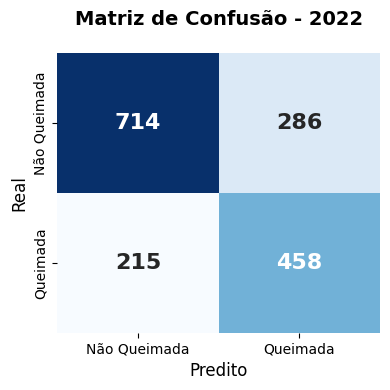


INTERPRETAÇÃO DA MATRIZ DE CONFUSÃO
VP (Verdadeiros Positivos): 458 - Células com áreas queimadas que foram identificadas corretamente
VN (Verdadeiros Negativos): 714 - Células sem áreas queimadas que foram identificadas corretamente
FP (Falsos Positivos): 286 - Alarmes falsos
FN (Falsos Negativos): 215 - Incêndios perdidos


In [3]:
# ============================================
# MATRIZ DE CONFUSÃO
# ============================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular matriz de confusão
cm = confusion_matrix(y_test, y_pred)

# Extrair valores
vn, fp, fn, vp = cm.ravel()

# Exibir matriz em texto
#print("Matriz de confusão (2022):")
#print("          Predito Classe 0  Predito Classe 1")
#print(f"Real classe 0:       {vn:>6}             {fp:>6}")
#print(f"Real Classe 1:           {fn:>6}             {vp:>6}")


# ============================================
# PLOT DA MATRIZ DE CONFUSÃO
# ============================================

fig, ax = plt.subplots(figsize=(4, 4))

# Criar heatmap com seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Queimada', 'Queimada'],
            yticklabels=['Não Queimada', 'Queimada'],
            ax=ax,
            cbar=False,
            annot_kws={'size': 16, 'weight': 'bold'})

# Configurar título e rótulos
ax.set_title('Matriz de Confusão - 2022', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Predito', fontsize=12)
ax.set_ylabel('Real', fontsize=12)

# Ajustar layout
plt.tight_layout()

# Salvar figura
plt.savefig('/content/matriz_confusao_diario_2022.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n" + "="*50)
print("INTERPRETAÇÃO DA MATRIZ DE CONFUSÃO")
print("="*50)
print(f"VP (Verdadeiros Positivos): {vp:,} - Células com áreas queimadas que foram identificadas corretamente")
print(f"VN (Verdadeiros Negativos): {vn:,} - Células sem áreas queimadas que foram identificadas corretamente")
print(f"FP (Falsos Positivos): {fp:,} - Alarmes falsos")
print(f"FN (Falsos Negativos): {fn:,} - Incêndios perdidos")

**5) *Trade-off Precision vs Recall***

A matriz de confusão apresentada anteriormente foi gerada a partir de um único limiar (*threshold*) de 0,5 (ou 50% de chance de a célula conter queimadas). No entanto, o limiar de decisão pode ser ajustado para atender diferentes necessidades operacionais, alterando o equilíbrio entre *precision* e *recall* (e aqui isso nos ajudará a visualizar os impactos dessas métricas em contextos operacionais).

**O que acontece quando ajustamos o *threshold*?**

- *Threshold* mais baixo (ex: 0,3) - cenário mais permissivo: o modelo se torna mais sensível, gerando mais alertas. Isso aumenta o *recall* (detecta mais incêndios), mas também aumenta os falsos alarmes (FP), reduzindo o *precision*.

- *Threshold* mais alto (ex: 0,7) - cenário mais restritivo: o modelo se torna mais conservador, gerando menos alertas. Isso reduz os falsos alarmes (FP), aumentando o *precision*, mas também aumenta os incêndios perdidos (FN), reduzindo o *recall*.

**Visualizando o *trade-off***

Os mapas abaixo mostram o comportamento do modelo para três thresholds diferentes: 0,3 (sensível), 0,5 (balanceado) e 0,7 (conservador). As cores na legenda significam:

- **VP (verde)**: áreas queimadas corretamente identificadas
- **VN (cinza)**: áreas não queimadas corretamente identificadas
- **FP (laranja)**: alarmes falsos
- **FN (vermelho)**: incêndios perdidos

**Interpretação dos resultados**

| Threshold | Comportamento | *Precision* | *Recall* | Consequência |
|-----------|---------------|-----------|--------|--------------|
| 0,3 | Sensível | menor | maior | Mais falsos alarmes, mas detecta mais incêndios |
| 0,5 | Balanceado | intermediário | intermediário | Equilíbrio entre custos |
| 0,7 | Conservador | maior | menor | Poucos falsos alarmes, mas perde mais incêndios |

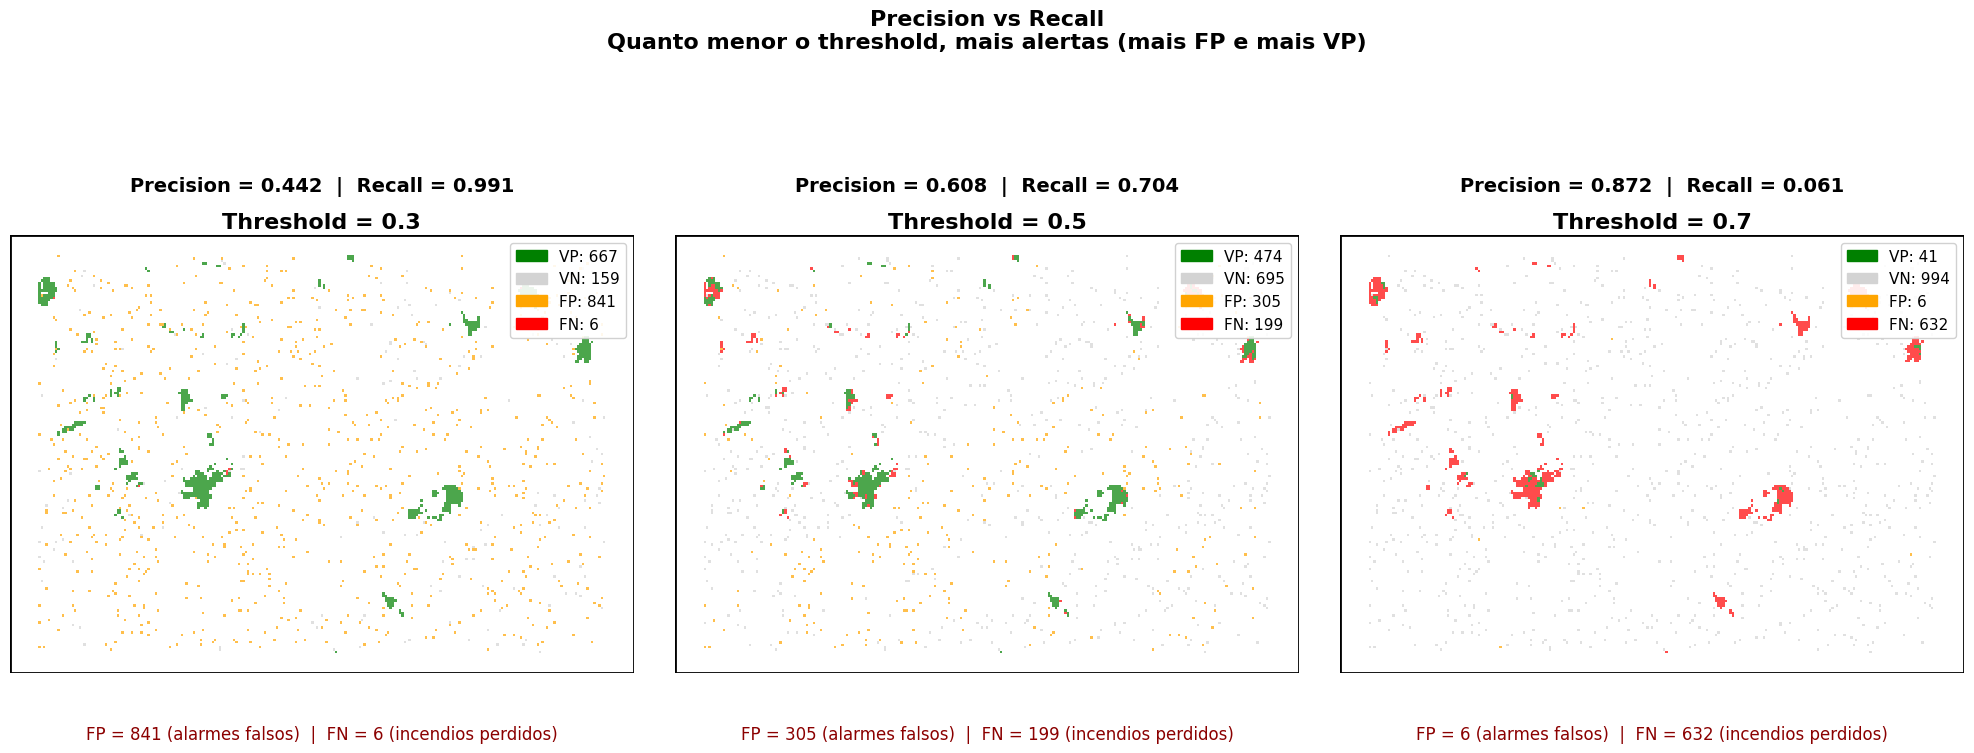


COMPARACAO DOS THRESHOLDS

Threshold  VP       FP       FN       VN       Precision    Recall      
----------------------------------------------------------------------
0.3        667      841      6        159      0.4423       0.9911      
0.5        474      305      199      695      0.6085       0.7043      
0.7        41       6        632      994      0.8723       0.0609      

INTERPRETACAO OPERACIONAL

Threshold = 0.3:
  Precision = 0.442  |  Recall = 0.991
  > Comportamento: SENSIVEL (threshold baixo)
  > Consequência: 841 falsos alarmes, mas detecta 667 incendios

Threshold = 0.5:
  Precision = 0.608  |  Recall = 0.704
  > Comportamento: BALANCEADO
  > Consequência: equilibrio entre 305 falsos alarmes e 199 incendios perdidos

Threshold = 0.7:
  Precision = 0.872  |  Recall = 0.061
  > Comportamento: CONSERVADOR (threshold alto)
  > Consequência: 632 incendios perdidos, mas poucos falsos alarmes


In [4]:
# ============================================
# TRADE-OFF PRECISION VS RECALL
# ============================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import geopandas as gpd
import pandas as pd
import numpy as np

# ============================================
# 1. PREPARAR DADOS ESPACIAIS
# ============================================

# Identificar coluna de indice
if 'index' in gdf.columns:
    coluna_idx = 'index'
elif 'indice' in gdf.columns:
    coluna_idx = 'indice'
elif 'id' in gdf.columns:
    coluna_idx = 'id'
else:
    gdf = gdf.reset_index()
    coluna_idx = 'index'

# Criar DataFrame com resultados
resultados = pd.DataFrame({
    'idx_original': idx_test,
    'y_true': y_test,
    'y_proba': y_proba
})

# Selecionar apenas a coluna de indice e a geometria do Geopackage
gdf_para_merge = gdf[[coluna_idx, 'geometry']].copy()

# Mesclar com o Geopackage
gdf_resultados = gdf_para_merge.merge(resultados,
                                      left_on=coluna_idx,
                                      right_on='idx_original',
                                      how='inner')

#print(f"Dados espaciais preparados: {len(gdf_resultados)} celulas")

# ============================================
# 2. FUNCAO PARA CLASSIFICAR
# ============================================

def classificar_celula(row, threshold):
    y_pred = 1 if row['y_proba'] >= threshold else 0
    if row['y_true'] == 1 and y_pred == 1:
        return 'VP'
    elif row['y_true'] == 0 and y_pred == 1:
        return 'FP'
    elif row['y_true'] == 1 and y_pred == 0:
        return 'FN'
    else:
        return 'VN'

# ============================================
# 3. CALCULAR PARA CADA THRESHOLD
# ============================================

thresholds = [0.3, 0.5, 0.7]
resultados_threshold = {}

for thresh in thresholds:
    y_pred = (y_proba >= thresh).astype(int)
    vp = np.sum((y_test == 1) & (y_pred == 1))
    fp = np.sum((y_test == 0) & (y_pred == 1))
    fn = np.sum((y_test == 1) & (y_pred == 0))
    vn = np.sum((y_test == 0) & (y_pred == 0))

    precision = vp / (vp + fp) if (vp + fp) > 0 else 0
    recall = vp / (vp + fn) if (vp + fn) > 0 else 0

    resultados_threshold[thresh] = {
        'vp': vp, 'fp': fp, 'fn': fn, 'vn': vn,
        'precision': precision, 'recall': recall
    }

# ============================================
# 4. PLOTAR MAPAS (UM POR THRESHOLD)
# ============================================

# Aumentar o tamanho da figura para melhor legibilidade
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for i, thresh in enumerate(thresholds):
    ax = axes[i]
    r = resultados_threshold[thresh]

    # Classificar celulas
    gdf = gdf_resultados.copy()
    gdf['classe'] = gdf.apply(lambda row: classificar_celula(row, thresh), axis=1)

    # Cores
    cores = {
        'VP': 'green',
        'VN': 'lightgray',
        'FP': 'orange',
        'FN': 'red'
    }

    # Plotar
    for classe, cor in cores.items():
        subset = gdf[gdf['classe'] == classe]
        if len(subset) > 0:
            subset.plot(ax=ax, color=cor, edgecolor='none', alpha=0.7)

    # Frame
    ax.set_axis_off()
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    ax.add_patch(Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                          fill=False, edgecolor='black', linewidth=2, zorder=100))

    # Titulo
    ax.set_title(f'Threshold = {thresh}', fontsize=16, fontweight='bold', pad=5)

    # Metrica na parte superior
    ax.text(0.5, 1.10,
            f'Precision = {r["precision"]:.3f}  |  Recall = {r["recall"]:.3f}',
            transform=ax.transAxes, ha='center', fontsize=14, fontweight='bold')

    # Destaque para os erros
    ax.text(0.5, -0.15,
            f'FP = {r["fp"]} (alarmes falsos)  |  FN = {r["fn"]} (incendios perdidos)',
            transform=ax.transAxes, ha='center', fontsize=12, color='darkred')

    # Legenda - ajustada para melhor visualização
    legend_elements = [
        mpatches.Patch(color='green', label=f'VP: {r["vp"]}'),
        mpatches.Patch(color='lightgray', label=f'VN: {r["vn"]}'),
        mpatches.Patch(color='orange', label=f'FP: {r["fp"]}'),
        mpatches.Patch(color='red', label=f'FN: {r["fn"]}')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11, framealpha=0.9)

# Titulo geral - ajustado para nao sobrepor
fig.suptitle('Precision vs Recall\n'
             'Quanto menor o threshold, mais alertas (mais FP e mais VP)',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# ============================================
# 5. TABELA COMPARATIVA
# ============================================

print("\n" + "="*60)
print("COMPARACAO DOS THRESHOLDS")
print("="*60)
print(f"\n{'Threshold':<10} {'VP':<8} {'FP':<8} {'FN':<8} {'VN':<8} {'Precision':<12} {'Recall':<12}")
print("-"*70)

for thresh in thresholds:
    r = resultados_threshold[thresh]
    print(f"{thresh:<10.1f} {r['vp']:<8} {r['fp']:<8} {r['fn']:<8} {r['vn']:<8} "
          f"{r['precision']:<12.4f} {r['recall']:<12.4f}")

print("\n" + "="*60)
print("INTERPRETACAO OPERACIONAL")
print("="*60)

for thresh in thresholds:
    r = resultados_threshold[thresh]
    print(f"\nThreshold = {thresh}:")
    print(f"  Precision = {r['precision']:.3f}  |  Recall = {r['recall']:.3f}")
    if thresh == 0.3:
        print("  > Comportamento: SENSIVEL (threshold baixo)")
        print(f"  > Consequência: {r['fp']} falsos alarmes, mas detecta {r['vp']} incendios")
    elif thresh == 0.7:
        print("  > Comportamento: CONSERVADOR (threshold alto)")
        print(f"  > Consequência: {r['fn']} incendios perdidos, mas poucos falsos alarmes")
    else:
        print("  > Comportamento: BALANCEADO")
        print(f"  > Consequência: equilibrio entre {r['fp']} falsos alarmes e {r['fn']} incendios perdidos")

**Qual *threshold* escolher?**

Essa é a “pergunta de um milhão de reais” e a resposta é: **depende do custo relativo dos erros que estamos dispostos a aceitar**.

O limiar/*threshold* não determina se o modelo “está certo ou errado”. Ele define o ponto de corte usado para transformar a saída contínua do modelo (y_proba) em uma decisão binária: área queimada *vs.* área não queimada. Alterar esse ponto de corte muda diretamente o equilíbrio entre *precision* e *recall*.

***Threshold* baixo: priorizando a detecção**

Quando reduzimos o limiar, por exemplo, para 0,3, passamos a classificar como área queimada todas as células cuja probabilidade, ou pontuação prevista pelo modelo, seja igual ou superior a 0,3. Nesse cenário, o *recall* aumenta, pois o modelo passa a identificar uma proporção maior das áreas que realmente queimaram. Nos nossos resultados, o *recall* chega a 0,991, ou seja, aproximadamente 99% das células realmente queimadas foram corretamente identificadas.

Por outro lado... o *precision* diminui para 0,44, significando que, de todas as células classificadas pelo modelo como áreas queimadas, cerca de 44% eram, de fato, queimadas. As demais eram falsos positivos. Esse comportamento é importante porque **um modelo com alto *recall* pode ser muito eficiente para não deixar passar eventos reais, mas ao custo de produzir mais falsos alarmes**.

As implicações práticas podem incluir:

a) Combate e monitoramento de incêndios: se os alertas forem usados para orientar as equipes de campo, o sistema terá maior chance de não deixar incêndios reais passarem despercebidos. O problema é que isso vem acompanhado de muitos falsos alarmes. No nosso exemplo, são 841 falsos positivos contra apenas 6 falsos negativos. Na prática, isso significa que as equipes podem ser enviadas para locais que, ao chegarem em campo, não apresentam evidências de incêndio (gastando tempo e dinheiro).

b) Estimativas de área queimada e carbono: se esse tipo de classificação for utilizado diretamente para produzir um mapa de áreas queimadas, os falsos positivos podem fazer com que a área queimada seja superestimada. Consequentemente, se as estimativas de emissões de carbono forem calculadas a partir dessa área, elas também podem ser superestimadas.

***Threshold* alto: priorizando a confiabilidade das detecções**

Agora vamos mudar o cenário. Ao aumentarmos o limiar para 0,7, o modelo se torna mais restritivo: somente as células com valores previstos iguais ou superiores a 0,7 são classificadas como áreas queimadas. Nesse caso, ocorre uma forte redução do número de falsos positivos. No nosso exemplo, temos apenas 6 falsos positivos.

Será que podemos concluir que isso é necessariamente bom? Dependendo da aplicação isso até pode ser desejável, mas o custo é alto, dado que o *recall* cai para apenas 0,061. Ou seja, o modelo identifica corretamente somente cerca de 6% das células que realmente queimaram. As outras 94 são classificadas como não queimadas, representando os falsos negativos.

Portanto, **embora as poucas áreas classificadas como queimadas sejam relativamente mais confiáveis** (o *precision* é 0,872), **o modelo deixa de detectar uma parcela muito grande das áreas que efetivamente queimaram**.

Exemplos de implicações práticas:

a) Combate e monitoramento de incêndios: um sistema com esse comportamento pode reduzir significativamente o número de falsos alarmes e, portanto, tornar os alertas mais seletivos. Pode ser útil quando os recursos de campo são muito limitados e o custo de deslocar uma equipe para uma área que não queimou é particularmente elevado. Porém, muitos incêndios ou áreas queimadas reais não serão detectados pelo sistema.

b) Estimativas de área queimada e carbono: se o mapa produzido for utilizado para estimar a extensão das áreas queimadas, o grande número de falsos negativos tende a produzir uma subestimativa da área efetivamente queimada. Consequentemente, uma estimativa de emissões de carbono baseada diretamente nessa área também poderá ser subestimada.

Em outras palavras, um *threshold* = 0,7 adota uma estratégia mais conservadora: reduz os falsos alarmes, mas aceita perder uma grande quantidade de eventos reais.


<small>O DeepSeek foi utilizado na padronização dos códigos.</small>

**Conclusão**

**O limiar de 0,5**

Por fim, podemos observar que um limiar de 0,5 oferece um melhor compromisso entre *precision* e *recall*.

No nosso caso, portanto, ele pode ser uma escolha razoável para a binarização das previsões. Aliás, no Jupyter Notebook 4, avaliamos os modelos utilizando o *F1-score*, uma métrica que combina *precision* e *recall* em uma única medida, buscando justamente esse equilíbrio entre as duas.

Link para o dataset: https://doi.org/10.57760/sciencedb.14040

**Bio**

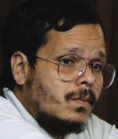

Alisson de Oliveira é Bacharel em Gestão e Análise Ambiental pela Universidade Federal de São Carlos (UFSCar) desde 2021 e Mestre em Sensoriamento Remoto pelo Instituto Nacional de Pesquisas Espaciais (INPE) desde 2024. Atualmente está no terceiro ano do doutorando em Sensoriamento Remoto no INPE, onde desenvolve pesquisas voltadas à análise ambiental utilizando dados de sensoriamento remoto e *machine learning*, como foco na utilização dos satélites brasileiros CBERS-4, CBERS-4A e AMAZONIA-1